<a href="https://colab.research.google.com/github/ivanriuk/Tarea4_Optimizacion2/blob/main/ANT_VRP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
#import Pkg; Pkg.add("Distances")
#import Pkg; Pkg.add("PrettyTables")

In [46]:
using Plots
using Distances
using Random
using DataFrames
using PrettyTables

# Instances
https://galgos.inf.puc-rio.br/cvrplib/index.php/en/instances

In [47]:
function read_cvrp_instance(filepath)
    lines = readlines(filepath)

    name = ""
    optimal_value = nothing
    num_nodes = 0
    capacity = 0

    coords = Dict{Int, Tuple{Float64, Float64}}()
    demands = Dict{Int, Int}()

    section = ""

    for line in lines
        line = strip(line)

        if isempty(line)
            continue
        end

        if startswith(line, "NAME")
            name = strip(split(line, ":")[2])

        elseif startswith(line, "COMMENT")
            m = match(r"Optimal value:\s*([0-9]+)", line)
            if m !== nothing
                optimal_value = parse(Int, m.captures[1])
            end

        elseif startswith(line, "DIMENSION")
            num_nodes = parse(Int, strip(split(line, ":")[2]))

        elseif startswith(line, "CAPACITY")
            capacity = parse(Int, strip(split(line, ":")[2]))

        elseif line == "NODE_COORD_SECTION"
            section = "coords"

        elseif line == "DEMAND_SECTION"
            section = "demands"

        elseif line == "DEPOT_SECTION"
            section = "depot"

        elseif line == "EOF"
            break

        else
            parts = split(line)

            if section == "coords"
                node = parse(Int, parts[1])
                x = parse(Float64, parts[2])
                y = parse(Float64, parts[3])
                coords[node] = (x, y)

            elseif section == "demands"
                node = parse(Int, parts[1])
                demand = parse(Int, parts[2])
                demands[node] = demand
            end
        end
    end

    return (
        name = name,
        optimal_value = optimal_value,
        num_nodes = num_nodes,
        capacity = capacity,
        coords = coords,
        demands = demands
    )
end

read_cvrp_instance (generic function with 1 method)

In [48]:
instance = read_cvrp_instance("/content/instances/A-n32-k5.vrp")

(name = "A-n32-k5", optimal_value = 784, num_nodes = 32, capacity = 100, coords = Dict(5 => (13.0, 7.0), 16 => (1.0, 65.0), 20 => (93.0, 3.0), 12 => (5.0, 10.0), 24 => (42.0, 9.0), 28 => (57.0, 69.0), 8 => (84.0, 39.0), 17 => (88.0, 51.0), 30 => (20.0, 70.0), 1 => (82.0, 76.0)…), demands = Dict(5 => 19, 16 => 22, 20 => 24, 12 => 14, 24 => 8, 28 => 20, 8 => 16, 17 => 18, 30 => 2, 1 => 0…))

In [49]:
name = instance.name
num_nodes = instance.num_nodes
capacity = instance.capacity
coords = instance.coords
demands = instance.demands
optimal_value = instance.optimal_value

784

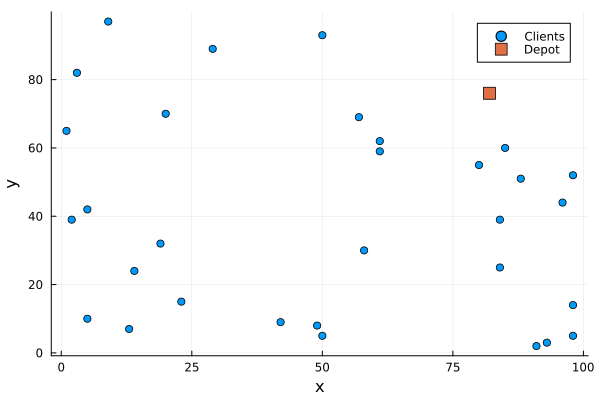

In [50]:
# depot cord
x_d, y_d = instance.coords[1]

# client cord
client_ids = 2:instance.num_nodes
x_c = [instance.coords[i][1] for i in 2:instance.num_nodes]
y_c = [instance.coords[i][2] for i in 2:instance.num_nodes]

scatter(
    x_c, y_c,
    label = "Clients",
    xlabel = "x",
    ylabel = "y",
    marker = (:circle, 4),
    legend = :topright
)

scatter!(
    [x_d], [y_d],
    label = "Depot",
    marker = (:square, 6)
)

In [51]:
function prob_values(
  num_nodes::Int,
  coords,
  demands
)

# =========================================
# 1) Encontramos la matriz de costos
# =========================================

coord = zeros(Float64, 2, num_nodes)

coord[1, :] = [coords[i][1] for i in 1:num_nodes]
coord[2, :] = [coords[i][2] for i in 1:num_nodes]

d = pairwise(Euclidean(), coord, dims=2) #matriz costos

# =========================================
# 2) Preparamos para la inicializacion tau y n
# =========================================

tau = fill(1.0, num_nodes, num_nodes) #feromonas

# evitamos que se pueda mover al mismo nodo i => i
for i in 1:num_nodes
  tau[i, i] = 0.0
end

eta = zeros(Float64, num_nodes, num_nodes) # heuristica original

for i in 1:num_nodes
  for j in 1:num_nodes
    if i != j && d[i, j] > 0
      eta[i, j] = 1.0 / d[i, j]
    else
      eta[i, j] = 0.0
    end
  end
end

mu = zeros(Float64, num_nodes, num_nodes) #"savings measure" para el vrp especifico

    for i in 1:num_nodes
        for j in 1:num_nodes
            if i != j && i != 1 && j != 1
                saving = d[i, 1] + d[1, j] - d[i, j]

                # redondeamos evitando tener valores negativos
                mu[i, j] = max(saving, 0.0)
            else
                mu[i, j] = 0.0
            end
        end
    end


return(
  d = d,
  tau = tau,
  eta = eta,
  mu = mu
)

end

prob_values (generic function with 1 method)

In [52]:
# =========================================
# funcion para escoger entre los nodos factibles
# seleccion por ruleta en base a las probabilidades de select_next_customer
# =========================================

function roulette_select(candidates, prob_final; rng = Random.GLOBAL_RNG)
    # peso total de todos los candidatos
    total = sum(prob_final)

    # si los pesos son cero o invalidos
    if total <= 0 || !isfinite(total)
        return rand(rng, candidates) # elegimos un candidato al azar
    end

    # valor aleatorio entre 0 y el peso total
    r = rand(rng) * total
    cumulative = 0.0

    # seleccionamos el primer candidato que supere el peso acumulado
    for (candidate, weight) in zip(candidates, prob_final)
        cumulative += weight
        # crea intervalos
        # 0.0 ───── 2.0 ───────────── 7.0 ─────── 10.0
        #      [1]           [2]            [3]

        # checa si para el candidato actual, r esta dentro de su rango
        if r <= cumulative
            return candidate
        end
    end

    # Retorno de seguridad por posibles errores numéricos // chat recomendacion
    return candidates[end]
end

roulette_select (generic function with 1 method)

In [53]:
function select_next_customer(
    current_node,
    feasible_customers,
    current_load,
    capacity,
    demands,
    tau,
    eta,
    mu;
    depot_id = 1,
    alpha = 5.0,
    beta = 5.0,
    gamma = 5.0,
    lambda = 5.0,
    rng = Random.GLOBAL_RNG,
    eps_term = 1e-12
)

    #probabilidad pij asociado a cada cliente factible
    prob_final = Float64[]

    for j in feasible_customers

        # que tan lleno quedaria el vehiculo si visitamos j
        # κij = (Qi + qj) / Q
        # mientras más cerca de 1 mejor
        kappa = (current_load + demands[j]) / capacity

        # checamos que mu solo se aplique si se va de nodo i a j
        # si se parte del depot mu = 1
        if current_node == depot_id
            mu_term = 1.0
        else
        # max sirve para evitar que tengamos un 0 exacto debido al redondeo
            mu_term = max(mu[current_node, j], eps_term)
        end

        tau_term = max(tau[current_node, j], eps_term)
        eta_term = max(eta[current_node, j], eps_term)
        kappa_term = max(kappa, eps_term)

        # calculamos la probabilidad de ir de i => j
        # del paper
        prob =
            (tau_term ^ alpha) *
            (eta_term ^ beta) *
            (mu_term ^ gamma) *
            (kappa_term ^ lambda)

        push!(prob_final, prob)
    end

    # elegimos un cliente usando selección tipo ruleta
    return roulette_select(feasible_customers, prob_final, rng = rng)
end

select_next_customer (generic function with 1 method)

In [54]:
# =========================================
# distancias entre 2 nodos
# =========================================
function route_length(route, d)
    total = 0.0

    for i in 1:(length(route) - 1)
        total += d[route[i], route[i + 1]] #usa la matriz de distancais previamente calculadas
    end

    return total
end

# =========================================
# funcion objetivo: distancia ruta total
# =========================================
function solution_length(routes, d)
    return sum(route_length(route, d) for route in routes)
end

solution_length (generic function with 1 method)

In [55]:
function construct_ant_solution(
    start_customer,
    num_nodes,
    capacity,
    demands,
    d,
    tau,
    eta,
    mu;
    depot_id = 1,
    alpha = 5.0,
    beta = 5.0,
    gamma = 5.0,
    lambda = 5.0,
    rng = Random.GLOBAL_RNG
)

    customers = collect(2:num_nodes)

    #check inicial no se sobrepase la capacidad
    if demands[start_customer] > capacity
        error("Nodo $start_customer tiene demanda mayor a la capacidad inicial")
    end

    # conjunto de clientes que todavía no han sido visitados por la hormiga
    # Set permite eliminar clientes fácilmente conforme se visitan
    unvisited = Set(customers)

    # aquí se guardarán todas las rutas construidas por esta hormiga
    routes = Vector{Vector{Int}}()

    # =========================================
    # inicio de la primera ruta
    # valores iniciales para la hormiga depot => cliente random
    # =========================================
    current_route = [depot_id, start_customer]
    current_node = start_customer
    current_load = demands[start_customer] #agarra el peso del cliente

    #eliminamos el cliente del set de nodos disponibles
    delete!(unvisited, start_customer)

    #mientras queden clientes sin asignar
    while !isempty(unvisited)

        #clientes factibles (quepan en la hormiga)
        feasible_customers = [
            j for j in unvisited
            if current_load + demands[j] <= capacity
        ]

        # =========================================
        # Caso 1: ya no cabe ningún cliente en la ruta actual
        # se genera hormiga nueva
        # =========================================
        if isempty(feasible_customers)
            # regresamos al deposito
            push!(current_route, depot_id)

            # guardamos la ruta completa en la lista de rutas
            push!(routes, current_route)

            # iniciamos una nueva ruta desde el depósito
            # buscamos clientes pendientes que puedan ser atendidos
            feasible_from_depot = [
                j for j in unvisited
                if demands[j] <= capacity
            ]

            #check de que la instancia total sea factible
            if isempty(feasible_from_depot)
                error("No hay suficiente capacidad para la demanda del problema")
            end

            # elegimos el primer cliente de la nueva ruta
            # la hormiga está saliendo desde el depósito => current_node = depot_id y current_load = 0.
            next_customer = select_next_customer(
                depot_id,
                feasible_from_depot,
                0,
                capacity,
                demands,
                tau,
                eta,
                mu;
                depot_id = depot_id,
                alpha = alpha,
                beta = beta,
                gamma = gamma,
                lambda = lambda,
                rng = rng
            )

            #ruta deposito => cleinte inicial
            #igual que antes
            current_route = [depot_id, next_customer]
            current_node = next_customer
            current_load = demands[next_customer]

            delete!(unvisited, next_customer)

        # =========================================
        # Caso 2: todavía hay clientes factibles para agregar
        # se continua con la hormiga
        # =========================================
        else
            next_customer = select_next_customer(
                current_node,
                feasible_customers,
                current_load,
                capacity,
                demands,
                tau,
                eta,
                mu;
                depot_id = depot_id,
                alpha = alpha,
                beta = beta,
                gamma = gamma,
                lambda = lambda,
                rng = rng
            )

            # actualizar ruta
            push!(current_route, next_customer)
            current_node = next_customer
            current_load += demands[next_customer]

            delete!(unvisited, next_customer)
        end
    end

    # Cuando ya no quedan clientes pendientes regresamos al deposito
    push!(current_route, depot_id)
    push!(routes, current_route)

    # costo total de la solución construida
    # funcion objetivo
    cost = solution_length(routes, d)

    return routes, cost
end

construct_ant_solution (generic function with 1 method)

In [56]:
function update_pheromones!(
    num_nodes,
    tau,
    ant_solutions,
    best_routes,
    best_cost;
    rho = 0.75,
    sigma = 1.0
)

    # =========================================
    # Evaporacion
    # lenta: rho > 1
    # rapida: rho > 0
    # =========================================
    for i in 1:num_nodes
        for j in 1:num_nodes
            tau[i, j] *= rho
        end
    end

    # =========================================
    # Nueva feromona de todas las hormigas
    # =========================================
    for (routes, cost) in ant_solutions
        # si una hormiga encontro una solucion con costo bajo, entonces libera mas feromona
        deposit = 1.0 / cost

        for route in routes
            # Recorremos cada arco de la ruta.
            for idx in 1:(length(route) - 1)
                i = route[idx]
                j = route[idx + 1]
                tau[i, j] += deposit # se coloca la feromona
            end
        end
    end

    # =========================================
    # elitismo
    # reforzamos la mejor solución encontrada hasta el momento
    # =========================================
    elite_deposit = sigma * (1.0 / best_cost) # sigma determina que tan fuerte es el elitismo

    for route in best_routes
        for idx in 1:(length(route) - 1)
            i = route[idx]
            j = route[idx + 1]
            tau[i, j] += elite_deposit
        end
    end

    # checamos que no se pueda mover del mismo nodo a si mismo
    for i in 1:num_nodes
        tau[i, i] = 0.0
    end
end

update_pheromones! (generic function with 1 method)

In [68]:
function ant_vrp(
    num_nodes,
    capacity,
    coords,
    demands;
    depot_id = 1,
    max_iter = 100,
    tau0 = 1.0, #feromona inicial
    alpha = 5.0, # fuerza de la feromona
    beta = 5.0, # fuerza de eta; 1/dij
    gamma = 5.0, # fuerza de mu; distancia entre nodos comparada con depot
    lambda = 5.0, # fuerza de kapa; demanda / capacidad i => j
    rho = 0.75, # evaporacion feromonas
    sigma =  1.0, #fuerza elitismo
    rounded_distances = true,
    rng = Random.GLOBAL_RNG
)

    # =========================================
    # matrices iniciales
    # =========================================
    d, tau, eta, mu = prob_values(num_nodes, coords, demands)

    # nodo 1 es el deposito // lista de clientes
    customers = collect(2:num_nodes)

    best_routes = Vector{Vector{Int}}()
    best_cost = Inf

    history = Float64[]

    # =========================================
    # Ciclo principal
    # en cada iteracion las hormigas construyen soluciones al CVRP
    # despues se actualizan las feromonas
    # =========================================

    for iter in 1:max_iter

        # las soluciones construidas por todas las hormigas
        ant_solutions = []

        # =========================================
        # construccion de soluciones
        # =========================================
        for start_customer in customers

            routes, cost = construct_ant_solution(
                start_customer,
                num_nodes,
                capacity,
                demands,
                d,
                tau,
                eta,
                mu;
                depot_id = depot_id,
                alpha = alpha,
                beta = beta,
                gamma = gamma,
                lambda = lambda,
                rng = rng
            )

            # se guarda la solucion
            push!(ant_solutions, (routes, cost))

            # se actualiza la mejor funcion objetivo y rutas
            if cost < best_cost
                best_cost = cost
                best_routes = routes
            end
        end

        # =========================================
        # actualizaciond de feromonas
        # =========================================
        update_pheromones!(
            num_nodes,
            tau,
            ant_solutions,
            best_routes,
            best_cost;
            rho = rho,
            sigma = sigma
        )

        # guardamos el mejor costo encontrado
        push!(history, best_cost)

        # ver las actualizaciones en vivo
        #println("Iteration $iter | Best cost = $best_cost")
    end

    return (
        best_routes = best_routes,
        best_cost = best_cost,
        history = history,
        d = d,
        tau = tau,
        eta = eta,
        mu = mu
    )
end

ant_vrp (generic function with 1 method)

In [69]:
result = ant_vrp(
    num_nodes,
    capacity,
    coords,
    demands;
    depot_id = 1,
    max_iter = 100,
    tau0 = 1.0,   #feromona inicial
    alpha = 5.0, # fuerza de la feromona
    beta = 5.0, # fuerza de eta; 1/dij
    gamma = 5.0, # fuerza de mu; distancia entre nodos comparada con depot
    lambda = 5.0, # fuerza de kapa; demanda / capacidad i => j
    rho = 0.75, # evaporacion feromonas
    sigma = 1.0, #fuerza elitismo
    rounded_distances = true,
    rng = Random.GLOBAL_RNG
)

(best_routes = [[1, 21, 6, 26, 11, 16, 10, 23, 19, 9, 30, 27, 1], [1, 31, 17, 2, 8, 14, 22, 15, 1], [1, 20, 18, 32, 3, 4, 24, 7, 1], [1, 25, 28, 5, 12, 29, 1], [1, 13, 1]], best_cost = 964.435844467965, history = [1053.3849333886267, 1030.2070471787179, 1030.2070471787179, 1014.6105105836481, 1014.6105105836481, 1014.6105105836481, 1014.6105105836481, 1014.6105105836481, 1014.6105105836481, 1014.6105105836481  …  964.435844467965, 964.435844467965, 964.435844467965, 964.435844467965, 964.435844467965, 964.435844467965, 964.435844467965, 964.435844467965, 964.435844467965, 964.435844467965], d = [0.0 34.92849839314596 … 16.278820596099706 72.78049189171504; 34.92849839314596 0.0 … 19.4164878389476 39.05124837953327; … ; 16.278820596099706 19.4164878389476 … 0.0 56.515484603779164; 72.78049189171504 39.05124837953327 … 56.515484603779164 0.0], tau = [0.0 0.007635628586391202 … 0.11055723065256681 0.01112980131378417; 0.004081702356044786 0.0 … 3.243392234921942e-13 3.2204553873376434e-13

In [70]:
result.best_cost

964.435844467965

In [71]:
for (r, route) in enumerate(result.best_routes)
    println("Route $r: ", route)
end

Route 1: [1, 21, 6, 26, 11, 16, 10, 23, 19, 9, 30, 27, 1]
Route 2: [1, 31, 17, 2, 8, 14, 22, 15, 1]
Route 3: [1, 20, 18, 32, 3, 4, 24, 7, 1]
Route 4: [1, 25, 28, 5, 12, 29, 1]
Route 5: [1, 13, 1]


In [72]:
function plot_routes(coords, routes, name; depot_id=1)

    # -------------------------------
    # Plot all clients first
    # -------------------------------
    client_ids = sort([i for i in keys(coords) if i != depot_id])
    x_clients = [coords[i][1] for i in client_ids]
    y_clients = [coords[i][2] for i in client_ids]

    p = scatter(
        x_clients, y_clients,
        label = "Clients",
        xlabel = "x",
        ylabel = "y",
        marker = (:circle, 4),
        legend = :topright,
        aspect_ratio = :equal,
        title = name
    )

    # -------------------------------
    # Plot depot
    # -------------------------------
    x_depot, y_depot = coords[depot_id]

    scatter!(
        p,
        [x_depot], [y_depot],
        label = "Depot",
        marker = (:square, 8)
    )

    # -------------------------------
    # Plot each route
    # -------------------------------
    for (r, route) in enumerate(routes)
        x_route = [coords[node][1] for node in route]
        y_route = [coords[node][2] for node in route]

        plot!(
            p,
            x_route, y_route,
            label = "Route $r",
            linewidth = 2,
            marker = (:circle, 3)
        )
    end

    # -------------------------------
    # Add node labels
    # -------------------------------
    for node in sort(collect(keys(coords)))
        x, y = coords[node]
        annotate!(p, x, y, text(string(node), 8))
    end

    return p
end

plot_routes (generic function with 1 method)

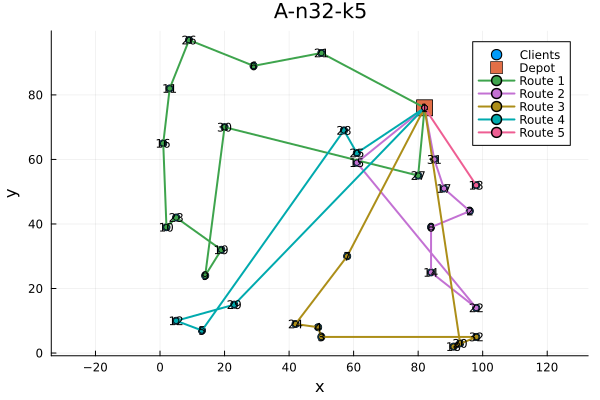

In [73]:
plot_routes(coords, result.best_routes, name)

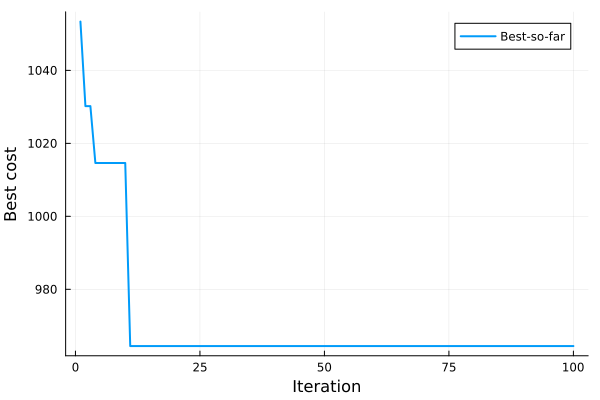

In [74]:
plot(
    result.history,
    xlabel = "Iteration",
    ylabel = "Best cost",
    label = "Best-so-far",
    linewidth = 2
)

In [75]:
function run_ant_instances(folderpath; seed = 06112002, ant_kwargs...)

    # lista de archivos .vrp dentro de la carpeta
    files = sort([
        file for file in readdir(folderpath)
        if endswith(lowercase(file), ".vrp")
    ])

    # tabla donde se guardarán los resultados
    results_table = DataFrame(
        Instancia = String[],
        Nodos = Int[],
        tiempo_ejecucion = Float64[],
        valor_objetivo_heuristica = Float64[],
        valor_objetivo_optimo= Union{Missing, Float64}[]
    )

    # semilla para reproducibilidad
    rng = Random.MersenneTwister(seed)

    for file in files
        filepath = joinpath(folderpath, file)

        println("Running instance: $file")

        # 1) Leer instancia
        instance = read_cvrp_instance(filepath)
        nodos = instance.num_nodes - 1

        # 2) aplicar algoritmo
        result = nothing

        tiempo = @elapsed begin
        result = ant_vrp(
            instance.num_nodes,
            instance.capacity,
            instance.coords,
            instance.demands;
            rng = rng,
            ant_kwargs...
        )
        end

        # 3) leer valor optimo
        opt_value = instance.optimal_value === nothing ? missing : Float64(instance.optimal_value)

        # 4) Guardar resultado en la tabla
        push!(
            results_table,
            (
                Instancia = String(instance.name),
                Nodos = nodos,
                tiempo_ejecucion = tiempo,
                valor_objetivo_heuristica = result.best_cost,
                valor_objetivo_optimo = opt_value
            )
        )
    end

    return results_table
end

run_ant_instances (generic function with 1 method)

In [76]:
tabla_result = run_ant_instances(
    "/content/instances";
    max_iter = 100,
    alpha = 5.0,
    beta = 5.0,
    gamma = 5.0,
    lambda = 5.0,
    rho = 0.75,
    sigma = 1.0
)

tabla_result

Running instance: A-n32-k5.vrp
Running instance: A-n33-k5.vrp
Running instance: A-n63-k9.vrp
Running instance: A-n64-k9.vrp
Running instance: A-n65-k9.vrp
Running instance: A-n69-k9.vrp
Running instance: A-n80-k10.vrp
Running instance: B-n31-k5.vrp
Running instance: B-n64-k9.vrp
Running instance: B-n66-k9.vrp
Running instance: B-n67-k10.vrp
Running instance: B-n68-k9.vrp
Running instance: B-n78-k10.vrp
Running instance: Golden_1.vrp
Running instance: Golden_2.vrp
Running instance: Golden_3.vrp


Row,Instancia,Nodos,tiempo_ejecucion,valor_objetivo_heuristica,valor_objetivo_optimo
,String,Int64,Float64,Float64,Float64?
1,A-n32-k5,31,0.409854,988.43,784.0
2,A-n33-k5,32,0.421752,749.633,661.0
3,A-n63-k9,62,2.5835,1814.17,1616.0
4,A-n64-k9,63,3.77733,1717.56,1401.0
5,A-n65-k9,64,3.04566,1434.43,1174.0
6,A-n69-k9,68,3.85859,1423.15,1159.0
7,A-n80-k10,79,6.60356,2172.89,1763.0
8,B-n31-k5,30,0.334489,722.993,672.0
9,B-n64-k9,63,2.71945,976.115,861.0


In [77]:
pretty_table(tabla_result)

┌───────────┬───────┬──────────────────┬───────────────────────────┬────────────
│ Instancia │ Nodos │ tiempo_ejecucion │ valor_objetivo_heuristica │ valor_obj ⋯
│    String │ Int64 │          Float64 │                   Float64 │           ⋯
├───────────┼───────┼──────────────────┼───────────────────────────┼────────────
│  A-n32-k5 │    31 │         0.409854 │                    988.43 │           ⋯
│  A-n33-k5 │    32 │         0.421752 │                   749.633 │           ⋯
│  A-n63-k9 │    62 │           2.5835 │                   1814.17 │           ⋯
│  A-n64-k9 │    63 │          3.77733 │                   1717.56 │           ⋯
│  A-n65-k9 │    64 │          3.04566 │                   1434.43 │           ⋯
│  A-n69-k9 │    68 │          3.85859 │                   1423.15 │           ⋯
│ A-n80-k10 │    79 │          6.60356 │                   2172.89 │           ⋯
│  B-n31-k5 │    30 │         0.334489 │                   722.993 │           ⋯
│  B-n64-k9 │    63 │       